In [1]:
# ── Imports ──
# V6 changes vs V5:
#   - Removed circular HR rolling features (hr_lag1, hr_avg_7, hr_avg_15)
#   - Removed duplicate windows — 15-day only for all Statcast metrics
#   - Added hr_zone_rate_15 — rolling % of batted balls in 25-35 degree launch angle band
#   - Removed park_factor_hr (redundant with park_factor)
#   - Added regularization grid search — tunes C via TimeSeriesSplit CV
import sys
sys.path.append("../scripts")

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from sqlalchemy import text
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, cross_val_score, GridSearchCV
from sklearn.metrics import roc_auc_score, accuracy_score
from pybaseball import statcast_batter
from data_collection import engine

In [2]:
# ── Load base dataset from database ──
with engine.connect() as conn:
    df = pd.read_sql(text("""
        SELECT
            w.game_id,
            w.date,
            w.season,
            w.home_away,
            w.tb,
            w.hr,
            w.opponent_id,
            p.throws,
            p.era,
            p.whip,
            p.k_per_9,
            p.era_last5,
            p.whip_last5,
            p.era_vs_rhb,
            b.bullpen_era,
            b.bullpen_whip,
            pf.park_factor,
            pf.park_factor_hr
        FROM witt_game_logs w
        JOIN pitcher_game_logs p ON w.game_id = p.game_id
        JOIN bullpen_stats b ON w.game_id = b.game_id
        JOIN park_factors pf ON (
            CASE WHEN w.home_away = 'home' THEN 118
                 ELSE w.opponent_id
            END = pf.team_id
        )
        ORDER BY w.date
    """), conn)

print(f"Base dataset: {df.shape}")
print(df[['date', 'hr', 'tb']].head(10))

Base dataset: (626, 18)
         date  hr  tb
0  2022-04-07   0   2
1  2022-04-09   0   0
2  2022-04-10   0   2
3  2022-04-11   0   0
4  2022-04-12   0   0
5  2022-04-14   0   3
6  2022-04-15   0   0
7  2022-04-16   0   2
8  2022-04-19   0   0
9  2022-04-20   0   0


In [3]:
# ── HR distribution and base rate ──
print("HR distribution:")
print(df['hr'].value_counts().sort_index())

hr_rate = (df['hr'] >= 1).mean()
print(f"\nGames with 0 HR:  {(df['hr'] == 0).mean():.3f}")
print(f"Games with 1+ HR: {hr_rate:.3f} ({hr_rate*100:.1f}% of games)")
print(f"Games with 2+ HR: {(df['hr'] >= 2).mean():.3f}")

breakeven = -hr_rate / (1 - hr_rate) * 100
print(f"\nBreak-even American odds: {breakeven:.0f}")
print(f"Book must offer better than {breakeven:.0f} for base rate edge")

HR distribution:
hr
0    527
1     93
2      6
Name: count, dtype: int64

Games with 0 HR:  0.842
Games with 1+ HR: 0.158 (15.8% of games)
Games with 2+ HR: 0.010

Break-even American odds: -19
Book must offer better than -19 for base rate edge


In [4]:
# ── Pull Statcast data via pybaseball ──
# Pitch-level data — batted ball metrics for Witt 2022-2025
print("Pulling Statcast data...")
statcast_raw = statcast_batter('2022-04-01', '2025-10-01', player_id=677951)
print(f"Statcast raw: {statcast_raw.shape}")

Pulling Statcast data...
Gathering Player Data
Statcast raw: (10689, 118)


In [5]:
# ── Aggregate Statcast to game level ──
# Filter to batted balls only — NaN launch_speed = pitch not put in play
batted = statcast_raw[statcast_raw['launch_speed'].notna()].copy()

# HR zone: 25-35 degree launch angle — the band where balls most frequently leave the park
# Captures swing plane tendency independent of exit velocity
batted['in_hr_zone'] = batted['launch_angle'].between(25, 35).astype(int)

game_stats = batted.groupby('game_date').agg(
    avg_exit_velo=('launch_speed', 'mean'),
    # Barrel = launch_speed_angle 6 — optimal exit velo + launch angle combo
    barrel_count=('launch_speed_angle', lambda x: (x == 6).sum()),
    # Hard hit = 95mph+ exit velocity
    hard_hit_count=('launch_speed', lambda x: (x >= 95).sum()),
    # HR zone = batted balls landing in 25-35 degree launch angle band
    hr_zone_count=('in_hr_zone', 'sum'),
    batted_balls=('launch_speed', 'count'),
).reset_index()

game_stats['barrel_rate']   = game_stats['barrel_count']   / game_stats['batted_balls']
game_stats['hard_hit_rate'] = game_stats['hard_hit_count'] / game_stats['batted_balls']
game_stats['hr_zone_rate']  = game_stats['hr_zone_count']  / game_stats['batted_balls']

print(f"Game-level Statcast: {game_stats.shape}")
print(game_stats[['game_date', 'barrel_rate', 'hr_zone_rate']].head(10))

Game-level Statcast: (641, 9)
    game_date  barrel_rate  hr_zone_rate
0  2022-04-07          0.0      0.500000
1  2022-04-09          0.0      0.000000
2  2022-04-10          0.0      0.200000
3  2022-04-11          0.0      0.000000
4  2022-04-12          0.0      0.333333
5  2022-04-14          0.0      0.000000
6  2022-04-15          0.0      0.333333
7  2022-04-16          0.0      0.285714
8  2022-04-19          0.0      0.400000
9  2022-04-20          0.0      0.000000


In [6]:
# ── Rolling Statcast features — 15-day window only ──
# V6 change: single window per metric eliminates multicollinearity from paired 7/15-day features
# shift(1) prevents current game leaking into its own prediction
game_stats = game_stats.sort_values('game_date').reset_index(drop=True)

game_stats['avg_exit_velo_15'] = game_stats['avg_exit_velo'].shift(1).rolling(15, min_periods=7).mean()
game_stats['barrel_rate_15']   = game_stats['barrel_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hard_hit_rate_15'] = game_stats['hard_hit_rate'].shift(1).rolling(15, min_periods=7).mean()
game_stats['hr_zone_rate_15']  = game_stats['hr_zone_rate'].shift(1).rolling(15, min_periods=7).mean()

print(game_stats[['game_date', 'barrel_rate_15', 'hr_zone_rate_15']].head(20))

     game_date  barrel_rate_15  hr_zone_rate_15
0   2022-04-07             NaN              NaN
1   2022-04-09             NaN              NaN
2   2022-04-10             NaN              NaN
3   2022-04-11             NaN              NaN
4   2022-04-12             NaN              NaN
5   2022-04-14             NaN              NaN
6   2022-04-15             NaN              NaN
7   2022-04-16        0.000000         0.195238
8   2022-04-19        0.000000         0.206548
9   2022-04-20        0.000000         0.228042
10  2022-04-21        0.000000         0.205238
11  2022-04-22        0.000000         0.186580
12  2022-04-23        0.000000         0.191865
13  2022-04-24        0.000000         0.177106
14  2022-04-26        0.000000         0.164456
15  2022-04-27        0.000000         0.160899
16  2022-04-28        0.000000         0.127566
17  2022-04-29        0.008333         0.127566
18  2022-04-30        0.021667         0.114233
19  2022-05-02        0.021667         0

In [7]:
# ── Merge Statcast into base dataset ──
game_stats['game_date'] = pd.to_datetime(game_stats['game_date'])
df['date'] = pd.to_datetime(df['date'])

df = df.merge(
    game_stats[['game_date', 'avg_exit_velo_15', 'barrel_rate_15',
                'hard_hit_rate_15', 'hr_zone_rate_15']],
    left_on='date',
    right_on='game_date',
    how='left'
)

print(f"After merge: {df.shape}")
print(df[['avg_exit_velo_15', 'barrel_rate_15', 'hr_zone_rate_15']].isnull().sum())

After merge: (626, 23)
avg_exit_velo_15    7
barrel_rate_15      7
hr_zone_rate_15     7
dtype: int64


In [8]:
# ── Feature engineering ──
# V6 change: HR rolling features removed — they are endogenous (outcome of past HRs)
# and introduced sign-flipping multicollinearity in V5
df = df.sort_values('date').reset_index(drop=True)

df['is_home']   = (df['home_away'] == 'home').astype(int)
df['pitcher_r'] = (df['throws'] == 'R').astype(int)

# Drop rows missing Statcast rolling features (early season warmup period)
df_model = df.dropna(subset=['avg_exit_velo_15', 'barrel_rate_15',
                              'hr_zone_rate_15']).reset_index(drop=True)

print(f"Model dataset: {df_model.shape}")
print(df_model[['date', 'hr', 'barrel_rate_15', 'hr_zone_rate_15']].head(10))

Model dataset: (619, 25)
        date  hr  barrel_rate_15  hr_zone_rate_15
0 2022-04-16   0             0.0         0.195238
1 2022-04-19   0             0.0         0.206548
2 2022-04-20   0             0.0         0.228042
3 2022-04-21   0             0.0         0.205238
4 2022-04-22   0             0.0         0.186580
5 2022-04-23   0             0.0         0.191865
6 2022-04-24   0             0.0         0.177106
7 2022-04-26   0             0.0         0.164456
8 2022-04-27   0             0.0         0.160899
9 2022-04-28   0             0.0         0.127566


In [9]:
# ── Define features and binary target ──
# V6 feature set: 13 causally independent features
# Removed: hr_lag1, hr_avg_7, hr_avg_15 (endogenous)
# Removed: all 7-day Statcast windows (multicollinear with 15-day)
# Removed: park_factor_hr (redundant with park_factor)
# Added:   hr_zone_rate_15 (launch angle tendency — key for multi-player generalization)
FEATURES = [
    # Witt contact quality — independent of HR outcome
    'avg_exit_velo_15',
    'barrel_rate_15',
    'hard_hit_rate_15',
    'hr_zone_rate_15',   # % batted balls in 25-35 degree launch angle band
    # Game context
    'is_home',
    'pitcher_r',
    # Starter stats
    'era',
    'whip',
    'k_per_9',
    'era_last5',
    'era_vs_rhb',
    # Bullpen
    'bullpen_era',
    # Park
    'park_factor',
]

X = df_model[FEATURES]
y_binary = (df_model['hr'] >= 1).astype(int)

print(f"Features: {len(FEATURES)}")
print(f"Dataset: {X.shape}")
print(f"HR rate: {y_binary.mean():.3f} ({y_binary.sum()} HR games out of {len(y_binary)})")

Features: 13
Dataset: (619, 13)
HR rate: 0.160 (99 HR games out of 619)


In [10]:
# ── Scale features ──
# Logistic regression is sensitive to feature scale — StandardScaler required
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=FEATURES)

In [11]:
# ── Baseline ──
baseline_acc = 1 - y_binary.mean()
print(f"Baseline accuracy (always predict no HR): {baseline_acc:.3f}")
breakeven = -y_binary.mean() / (1 - y_binary.mean()) * 100
print(f"Break-even odds for HR prop: {breakeven:.0f}")

Baseline accuracy (always predict no HR): 0.840
Break-even odds for HR prop: -19


In [12]:
# ── Regularization tuning — grid search over C ──
# C controls regularization strength in logistic regression
# Low C = stronger regularization = simpler model, less overfit
# High C = weaker regularization = fits training data more closely
# GridSearchCV with TimeSeriesSplit finds the best C without leaking future data
#
# C candidates span 4 orders of magnitude — log scale is standard for regularization search
C_grid = [0.001, 0.01, 0.05, 0.1, 0.25, 0.5, 1.0, 2.0, 5.0, 10.0]

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    LogisticRegression(max_iter=500),
    param_grid={'C': C_grid},
    cv=tscv,
    scoring='roc_auc',
    refit=True,      # refit on full dataset with best C after search
    n_jobs=-1
)

grid_search.fit(X_scaled, y_binary)

best_C   = grid_search.best_params_['C']
best_auc = grid_search.best_score_

print(f"Best C:        {best_C}")
print(f"Best CV AUC:   {best_auc:.3f}")
print()

# Full results table
results = pd.DataFrame(grid_search.cv_results_)
print(results[['param_C', 'mean_test_score', 'std_test_score']].round(4).to_string(index=False))

Best C:        2.0
Best CV AUC:   0.555

 param_C  mean_test_score  std_test_score
   0.001           0.5333          0.0875
   0.010           0.5381          0.0823
   0.050           0.5461          0.0778
   0.100           0.5445          0.0803
   0.250           0.5485          0.0797
   0.500           0.5525          0.0841
   1.000           0.5540          0.0802
   2.000           0.5545          0.0759
   5.000           0.5541          0.0742
  10.000           0.5535          0.0734


In [13]:
# ── Cross-validation with best C ──
model = grid_search.best_estimator_

cv_auc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='roc_auc')
cv_acc = cross_val_score(model, X_scaled, y_binary, cv=tscv, scoring='accuracy')

print(f"CV AUC per fold:  {[round(v,3) for v in cv_auc]}")
print(f"CV ACC per fold:  {[round(v,3) for v in cv_acc]}")
print(f"\nAUC mean ± std:   {cv_auc.mean():.3f} ± {cv_auc.std():.3f}")
print(f"ACC mean ± std:   {cv_acc.mean():.3f} ± {cv_acc.std():.3f}")
print(f"\nBaseline ACC:     {baseline_acc:.3f}")
print(f"Improvement:      {cv_acc.mean() - baseline_acc:.3f}")
print(f"\nV5 CV AUC:        0.588  (baseline for comparison)")
print(f"V6 CV AUC:        {cv_auc.mean():.3f}")
print(f"\n(AUC > 0.55 = meaningful signal for sports betting)")

CV AUC per fold:  [np.float64(0.515), np.float64(0.635), np.float64(0.643), np.float64(0.443), np.float64(0.537)]
CV ACC per fold:  [np.float64(0.874), np.float64(0.777), np.float64(0.845), np.float64(0.845), np.float64(0.825)]

AUC mean ± std:   0.555 ± 0.076
ACC mean ± std:   0.833 ± 0.032

Baseline ACC:     0.840
Improvement:      -0.007

V5 CV AUC:        0.588  (baseline for comparison)
V6 CV AUC:        0.555

(AUC > 0.55 = meaningful signal for sports betting)


In [14]:
# ── Fit on full dataset ──
model.fit(X_scaled, y_binary)
df_model['p_hr'] = model.predict_proba(X_scaled)[:, 1]

insample_auc = roc_auc_score(y_binary, df_model['p_hr'])
insample_acc = accuracy_score(y_binary, model.predict(X_scaled))

print(f"In-sample AUC:  {insample_auc:.3f}")
print(f"In-sample ACC:  {insample_acc:.3f}")
print(f"CV AUC:         {cv_auc.mean():.3f}")
print(f"\nGap (in-sample - CV AUC): {insample_auc - cv_auc.mean():.3f}")
print("(smaller gap vs V5 = less overfitting)")
print(f"\nMean P(HR):     {df_model['p_hr'].mean():.3f}")
print(f"Actual HR rate: {y_binary.mean():.3f}")

In-sample AUC:  0.641
In-sample ACC:  0.842
CV AUC:         0.555

Gap (in-sample - CV AUC): 0.087
(smaller gap vs V5 = less overfitting)

Mean P(HR):     0.160
Actual HR rate: 0.160


In [15]:
# ── Calibration table ──
# When model assigns high probability, does HR actually happen more often?
# Spread between top and bottom bin is the key diagnostic
df_model['pred_bin'] = pd.qcut(df_model['p_hr'], q=5, labels=False)

calibration = df_model.groupby('pred_bin').agg(
    mean_predicted=('p_hr', 'mean'),
    actual_rate=('hr', lambda x: (x >= 1).mean()),
    n=('hr', 'count')
).round(3)

print(calibration)
spread = calibration['actual_rate'].iloc[-1] - calibration['actual_rate'].iloc[0]
print(f"\nSpread (bin 4 - bin 0): {spread:.3f}")
print(f"V5 spread:              ~0.12  (baseline for comparison)")
print("\n(larger spread = better discrimination between HR and non-HR games)")

          mean_predicted  actual_rate    n
pred_bin                                  
0                  0.075        0.081  124
1                  0.118        0.113  124
2                  0.153        0.146  123
3                  0.191        0.194  124
4                  0.263        0.266  124

Spread (bin 4 - bin 0): 0.185
V5 spread:              ~0.12  (baseline for comparison)

(larger spread = better discrimination between HR and non-HR games)


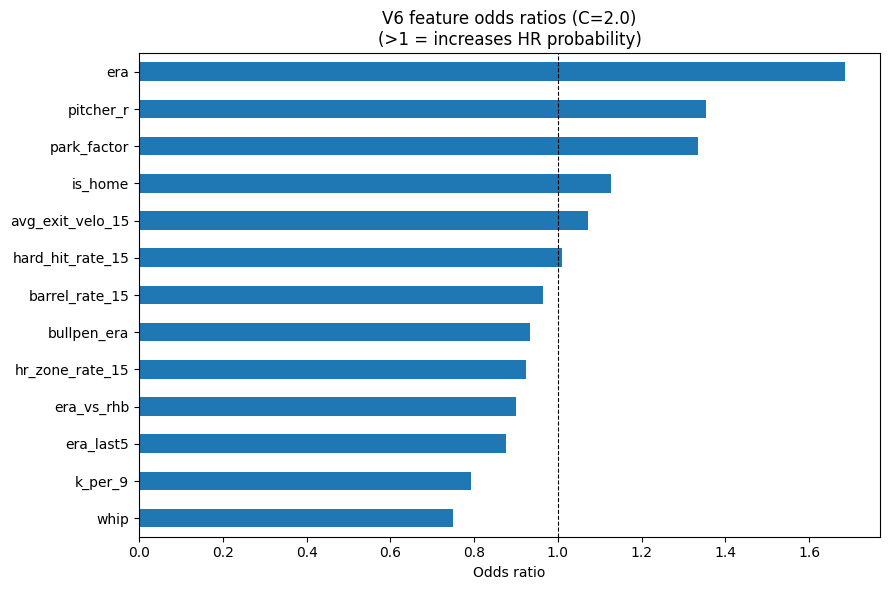


Odds ratios:
whip                0.749
k_per_9             0.792
era_last5           0.876
era_vs_rhb          0.900
hr_zone_rate_15     0.923
bullpen_era         0.933
barrel_rate_15      0.964
hard_hit_rate_15    1.011
avg_exit_velo_15    1.071
is_home             1.128
park_factor         1.335
pitcher_r           1.353
era                 1.685
dtype: float64


In [16]:
# ── Feature odds ratios ──
# exp(coef) = odds ratio
# >1 increases HR probability, <1 decreases it
# V6 coefficients should be cleaner — no sign-flipping from multicollinear pairs
coefs = pd.Series(model.coef_[0], index=FEATURES).sort_values()

fig, ax = plt.subplots(figsize=(9, 6))
np.exp(coefs).sort_values().plot(kind='barh', ax=ax)
ax.axvline(1.0, color='black', linestyle='--', linewidth=0.8)
ax.set_title(f'V6 feature odds ratios (C={best_C})\n(>1 = increases HR probability)')
ax.set_xlabel('Odds ratio')
plt.tight_layout()
plt.show()

print("\nOdds ratios:")
print(np.exp(coefs).round(3))

In [17]:
# ── Implied odds converter ──
def prob_to_american_odds(p):
    if p >= 0.5:
        return round(-p / (1 - p) * 100)
    else:
        return round((1 - p) / p * 100)

sample = df_model[['date', 'hr', 'p_hr']].copy()
sample['implied_odds'] = sample['p_hr'].apply(prob_to_american_odds)
sample['result'] = (sample['hr'] >= 1).map({True: '✅ HR', False: '❌ No HR'})

print("Last 20 games — model probability vs actual result:")
print(sample[['date', 'p_hr', 'implied_odds', 'result']].tail(20).to_string())

Last 20 games — model probability vs actual result:
          date      p_hr  implied_odds   result
599 2025-09-04  0.202427           394     ✅ HR
600 2025-09-05  0.137847           625  ❌ No HR
601 2025-09-09  0.048042          1982  ❌ No HR
602 2025-09-10  0.064986          1439  ❌ No HR
603 2025-09-11  0.108936           818  ❌ No HR
604 2025-09-12  0.245837           307  ❌ No HR
605 2025-09-13  0.203767           391  ❌ No HR
606 2025-09-14  0.223447           348     ✅ HR
607 2025-09-16  0.123119           712  ❌ No HR
608 2025-09-17  0.222522           349  ❌ No HR
609 2025-09-18  0.167238           498  ❌ No HR
610 2025-09-19  0.185656           439  ❌ No HR
611 2025-09-20  0.188340           431     ✅ HR
612 2025-09-21  0.075536          1224  ❌ No HR
613 2025-09-23  0.107774           828  ❌ No HR
614 2025-09-24  0.067941          1372  ❌ No HR
615 2025-09-25  0.125449           697  ❌ No HR
616 2025-09-26  0.314303           218  ❌ No HR
617 2025-09-27  0.280411           2

In [18]:
# ── Save model artifacts ──
joblib.dump(model,  '../models/witt_hr_logistic_v6_model.pkl')
joblib.dump(scaler, '../models/witt_hr_logistic_v6_scaler.pkl')
print("Saved:")
print("  models/witt_hr_logistic_v6_model.pkl")
print("  models/witt_hr_logistic_v6_scaler.pkl")
print(f"\nBest C: {best_C}")
print(f"Features ({len(FEATURES)}): {FEATURES}")

Saved:
  models/witt_hr_logistic_v6_model.pkl
  models/witt_hr_logistic_v6_scaler.pkl

Best C: 2.0
Features (13): ['avg_exit_velo_15', 'barrel_rate_15', 'hard_hit_rate_15', 'hr_zone_rate_15', 'is_home', 'pitcher_r', 'era', 'whip', 'k_per_9', 'era_last5', 'era_vs_rhb', 'bullpen_era', 'park_factor']
